# S&P 500 Stock Market Analytics & Price Prediction

## 1. Company Overview
AlphaQuant Capital is an investment research company focused on
quantitative trading and financial analytics. The company uses historical
S&P 500 stock market data to identify trends, assess stock performance,
and support data-driven investment decisions.

## 2. Business Problem
Stock-market data contains large amounts of daily price and trading-volume
information. AlphaQuant Capital needs a structured analysis to identify
high-performing and volatile stocks, understand the relationship between
volume and price changes, detect unusual movements, and predict future
closing prices.

## 3. Project Objectives
- Analyze historical prices of S&P 500 stocks from 2014 to 2017.
- Identify stocks with the highest returns and highest volatility.
- Study trading-volume and price-movement patterns.
- Create useful financial features such as returns and moving averages.
- Build regression models to predict stock closing prices.
- Generate practical business insights for investment decisions.

## 4. Scope
The project uses daily stock data containing symbol, date, open, high,
low, close, and volume. The analysis includes data cleaning, exploratory
data analysis, visualizations, feature engineering, statistical analysis,
machine-learning regression, and optional time-series forecasting.

## 5. Business Questions
1. Which stocks delivered the highest returns?
2. Which stocks were the most volatile?
3. How does trading volume affect price movement?
4. Can future closing prices be predicted?
5. Which stocks show similar trading behavior?
6. Which stocks show abnormal price or volume movements?
7. Which sectors outperform the market, if sector data is added?

## 6. Expected Outcomes
- A clean and well-documented stock-price dataset.
- Charts and statistical summaries of stock performance.
- Engineered features for predictive modelling.
- Multiple regression models evaluated using standard metrics.
- Investment insights and recommendations based on the analysis.

In [32]:
from google.colab import files

uploaded = files.upload()

Saving S&P 500 Stock Prices 2014-2017.csv to S&P 500 Stock Prices 2014-2017 (1).csv


In [33]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"S&P 500 Stock Prices 2014-2017.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 records:", df.head())
print("\nLast 5 records:", df.tail())
print("\nData Types:", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate records", df.duplicated().sum())
print("\nDescriptive Statistics:", df.describe())
print("\nUnique Stocks:", df["symbol"].nunique())
print("\nDate range:")
print("From:", df["date"].min())
print("To:", df["date"].max())

Dataset Shape: (497472, 7)

First 5 records:   symbol        date      open      high       low     close    volume
0    AAL  2014-01-02   25.0700   25.8200   25.0600   25.3600   8998943
1   AAPL  2014-01-02   79.3828   79.5756   78.8601   79.0185  58791957
2    AAP  2014-01-02  110.3600  111.8800  109.2900  109.7400    542711
3   ABBV  2014-01-02   52.1200   52.3300   51.5200   51.9800   4569061
4    ABC  2014-01-02   70.1100   70.2300   69.4800   69.8900   1148391

Last 5 records:        symbol        date    open    high     low   close   volume
497467    XYL  2017-12-29   68.53   68.80   67.92   68.20  1046677
497468    YUM  2017-12-29   82.64   82.71   81.59   81.61  1347613
497469    ZBH  2017-12-29  121.75  121.95  120.62  120.67  1023624
497470   ZION  2017-12-29   51.28   51.55   50.81   50.83  1261916
497471    ZTS  2017-12-29   72.55   72.76   72.04   72.04  1704122

Data Types: symbol     object
date       object
open      float64
high      float64
low       float64
close  

**Data Cleaning**

In [34]:
df_clean = df.copy()

df_clean["date"] = pd.to_datetime(df_clean["date"])

rows_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print("Duplicates removed:", rows_before - len(df_clean))


df_clean = df_clean.sort_values(["symbol", "date"]).reset_index(drop=True)


price_cols = ["open", "high", "low", "close"]

df_clean[price_cols] = (
    df_clean.groupby("symbol")[price_cols]
    .transform(lambda x: x.ffill().bfill()))


invalid_ohlc = df_clean[
    (df_clean["high"] < df_clean[["open", "close", "low"]].max(axis=1)) |
    (df_clean["low"] > df_clean[["open", "close", "high"]].min(axis=1)) ]


print("Invalid OHLC rows found:", len(invalid_ohlc))

df_clean = df_clean.drop(index=invalid_ohlc.index).reset_index(drop=True)

invalid_ohlc_final = df_clean[
    (df_clean["high"] < df_clean[["open", "close", "low"]].max(axis=1)) |
    (df_clean["low"] > df_clean[["open", "close", "high"]].min(axis=1)) ]


invalid_prices = df_clean[(df_clean[price_cols] <= 0).any(axis=1)]

print("\nFinal dataset shape:", df_clean.shape)
print("Missing values remaining:", df_clean.isnull().sum().sum())
print("Zero/negative price rows:", len(invalid_prices))
print("Invalid OHLC rows remaining:", len(invalid_ohlc_final))

display(df_clean.head())

Duplicates removed: 0
Invalid OHLC rows found: 13

Final dataset shape: (497459, 7)
Missing values remaining: 0
Zero/negative price rows: 0
Invalid OHLC rows remaining: 0


,symbol,date,open,high,low,close,volume
0,A,2014-01-02,57.10,57.100,56.15,56.21,1916160
1,A,2014-01-03,56.39,57.345,56.26,56.92,1866651
2,A,2014-01-06,57.40,57.700,56.56,56.64,1777472
3,A,2014-01-07,56.95,57.630,56.93,57.45,1463208
4,A,2014-01-08,57.33,58.540,57.17,58.39,2659468


**Exploratory Data Analysis**

In [35]:
print("Number of companies:", df_clean["symbol"].nunique())
print("Number of trading days:", df_clean["date"].nunique())

highest_close = df_clean.loc[
    df_clean["close"].idxmax(),
    ["symbol", "date", "close"]]


lowest_close = df_clean.loc[
    df_clean["close"].idxmin(),
    ["symbol", "date", "close"]]


print("\nHighest closing-price record:")
display(highest_close.to_frame().T)

print("\nLowest closing-price record:")
display(lowest_close.to_frame().T)

print("\nAverage closing price:", round(df_clean["close"].mean(), 2))
print("Total trading volume:", f'{df_clean["volume"].sum():,}')


company_summary = (
    df_clean.groupby("symbol")
    .agg(
        average_close=("close", "mean"),
        total_volume=("volume", "sum"),
        average_daily_volume=("volume", "mean"))

    .reset_index())

# 5. Top 20 companies by average closing price
top_20_avg_close = company_summary.sort_values(
    "average_close", ascending=False).head(20)

print("\nTop 20 companies by average closing price:")
display(top_20_avg_close)

# 6. Most traded companies: total volume across the full period
top_traded_companies = company_summary.sort_values(
    "total_volume", ascending=False).head(10)

print("\nTop 10 companies by total trading volume:")
display(top_traded_companies)

# 7. Highest average daily trading volume
highest_daily_volume = company_summary.sort_values(
    "average_daily_volume", ascending=False).head(10)

print("\nTop 10 companies by average daily trading volume:")
display(highest_daily_volume)

Number of companies: 505
Number of trading days: 1007

Highest closing-price record:


,symbol,date,close
354573,PCLN,2017-08-08 00:00:00,2049.0



Lowest closing-price record:


,symbol,date,close
93250,CHK,2016-02-12 00:00:00,1.59



Average closing price: 86.37
Total trading volume: 2,116,019,265,422

Top 20 companies by average closing price:


,symbol,average_close,total_volume,average_daily_volume
360,PCLN,1390.272642,637358724,6.329282e+05
207,GOOGL,722.559017,2121934159,2.107184e+06
206,GOOG,714.496848,1717579425,1.809883e+06
58,AZO,660.246425,323425210,3.211770e+05
38,AMZN,619.244787,3907285439,3.880125e+06
105,CMG,516.849355,908375634,9.020612e+05
393,REGN,412.335822,884738553,8.785884e+05
325,MTD,377.854131,173123302,1.719199e+05
71,BLK,359.971301,624875978,6.205323e+05
69,BIIB,310.474882,1742291933,1.730181e+06



Top 10 companies by total trading volume:


,symbol,average_close,total_volume,average_daily_volume
60,BAC,18.263083,89988444028,8.936290e+07
3,AAPL,116.839892,45485758169,4.516957e+07
200,GE,27.279270,41734050117,4.144394e+07
32,AMD,5.908605,33522535638,3.328951e+07
178,F,13.832264,33144701045,3.291430e+07
322,MSFT,54.084863,30927601441,3.071261e+07
180,FB,107.738043,29432418373,2.922782e+07
326,MU,24.445754,28158553783,2.796281e+07
95,CHK,11.740586,28072466547,2.790504e+07
247,INTC,33.403238,27351266285,2.716114e+07



Top 10 companies by average daily trading volume:


,symbol,average_close,total_volume,average_daily_volume
60,BAC,18.263083,89988444028,8.936290e+07
3,AAPL,116.839892,45485758169,4.516957e+07
200,GE,27.279270,41734050117,4.144394e+07
32,AMD,5.908605,33522535638,3.328951e+07
178,F,13.832264,33144701045,3.291430e+07
322,MSFT,54.084863,30927601441,3.071261e+07
180,FB,107.738043,29432418373,2.922782e+07
326,MU,24.445754,28158553783,2.796281e+07
95,CHK,11.740586,28072466547,2.790504e+07
247,INTC,33.403238,27351266285,2.716114e+07


**Returns, Volatility & Time Trends**

In [36]:
df_eda = df_clean.copy()
df_eda = df_eda.sort_values(["symbol", "date"]).reset_index(drop=True)

df_eda["daily_return"] = (
    df_eda.groupby("symbol")["close"]
    .pct_change(fill_method=None))

df_eda["rolling_volatility_30d"] = (
    df_eda.groupby("symbol")["daily_return"]
    .transform(lambda x: x.rolling(window=30, min_periods=30).std()))


df_eda["moving_average_30d"] = (
    df_eda.groupby("symbol")["close"]
    .transform(lambda x: x.rolling(window=30, min_periods=30).mean()))


df_eda["cumulative_return"] = (
    df_eda.groupby("symbol")["daily_return"]
    .transform(lambda x: (1 + x.fillna(0)).cumprod() - 1))


df_eda["month"] = df_eda["date"].dt.to_period("M")
df_eda["quarter"] = df_eda["date"].dt.to_period("Q")
df_eda["year"] = df_eda["date"].dt.year

print("Daily return distribution:")
display(df_eda["daily_return"].describe())

stock_volatility = (
    df_eda.groupby("symbol")["daily_return"]
    .std()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="daily_return_std"))

print("\nTop 10 most volatile stocks:")
display(stock_volatility)

monthly_trend = (
    df_eda.groupby("month")
    .agg(
        average_close=("close", "mean"),
        total_volume=("volume", "sum"),
        average_daily_return=("daily_return", "mean"))
    .reset_index())


print("\nMonthly trend:")
display(monthly_trend.head())

quarterly_trend = (
    df_eda.groupby("quarter")
    .agg(
        average_close=("close", "mean"),
        total_volume=("volume", "sum"),
        average_daily_return=("daily_return", "mean"))
    .reset_index())

print("\nQuarterly trend:")
display(quarterly_trend)

yearly_trend = (
    df_eda.groupby("year")
    .agg(
        average_close=("close", "mean"),
        total_volume=("volume", "sum"),
        average_daily_return=("daily_return", "mean"))
    .reset_index())

print("\nYearly trend:")
display(yearly_trend)


print("\nSample of engineered EDA columns:")
display(
    df_eda[
        ["symbol", "date", "close", "daily_return",
         "rolling_volatility_30d", "moving_average_30d",
         "cumulative_return"]
    ].head(35))

Daily return distribution:


,daily_return
count,496954.000000
mean,0.000459
std,0.016207
min,-0.626183
25%,-0.006814
50%,0.000581
75%,0.007995
max,0.522901



Top 10 most volatile stocks:


,symbol,daily_return_std
0,CHK,0.045542
1,AMD,0.039102
2,FCX,0.036989
3,BHGE,0.036615
4,WMB,0.032347
5,MRO,0.032164
6,EVHC,0.029553
7,RRC,0.029073
8,INCY,0.028560
9,UA,0.028433



Monthly trend:


...

,quarter,average_close,total_volume,average_daily_return
0,2014Q1,73.205917,140285378351,0.000735
1,2014Q2,75.911964,123770000720,0.000806
2,2014Q3,78.674411,113230319606,-0.000103
3,2014Q4,79.860114,132344073091,0.001129
4,2015Q1,83.658978,129770209275,0.000449
5,2015Q2,85.557092,120363169918,-0.000176
6,2015Q3,83.536284,143712776981,-0.001093
7,2015Q4,83.794061,141107384388,0.000784
8,2016Q1,79.212167,165311987749,0.000550
9,2016Q2,84.684868,138993379761,0.000457



Yearly trend:


,year,average_close,total_volume,average_daily_return
0,2014,76.970979,509629771768,0.000640
1,2015,84.135010,534953540562,-0.000014
2,2016,85.254823,571035653047,0.000559
3,2017,98.800312,500400300045,0.000650



Sample of engineered EDA columns:


,symbol,date,close,daily_return,rolling_volatility_30d,moving_average_30d,cumulative_return
0,A,2014-01-02,56.21,NaN,NaN,NaN,0.000000
1,A,2014-01-03,56.92,0.012631,NaN,NaN,0.012631
2,A,2014-01-06,56.64,-0.004919,NaN,NaN,0.007650
3,A,2014-01-07,57.45,0.014301,NaN,NaN,0.022060
4,A,2014-01-08,58.39,0.016362,NaN,NaN,0.038783
5,A,2014-01-09,58.41,0.000343,NaN,NaN,0.039139
6,A,2014-01-10,58.93,0.008903,NaN,NaN,0.048390
7,A,2014-01-13,58.93,0.000000,NaN,NaN,0.048390
8,A,2014-01-14,59.88,0.016121,NaN,NaN,0.065291
9,A,2014-01-15,60.34,0.007682,NaN,NaN,0.073474


**Data Visualization.**

Stocks used in charts: ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'JPM']


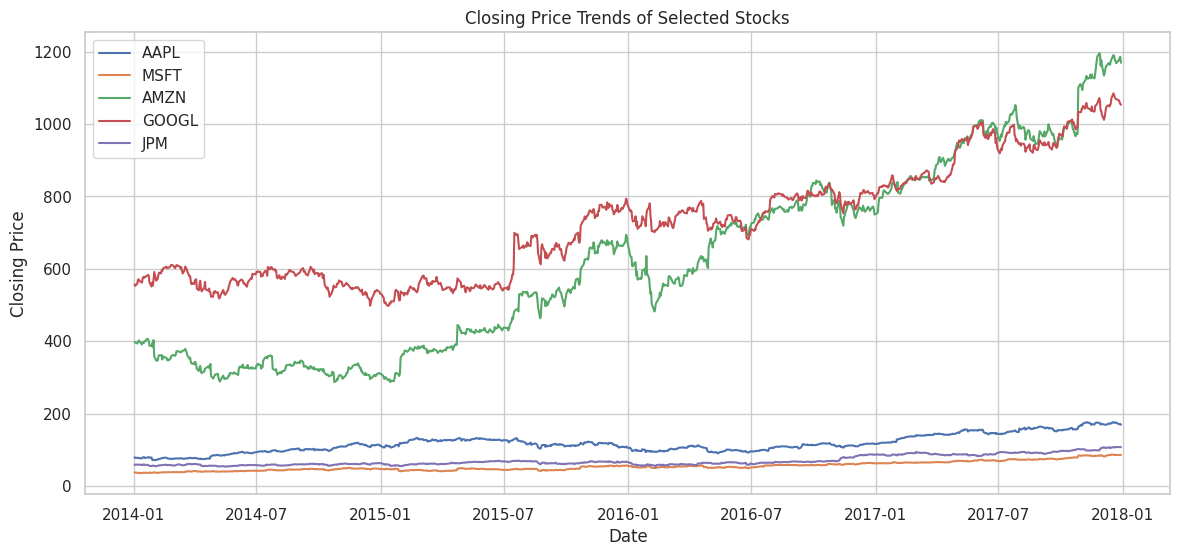

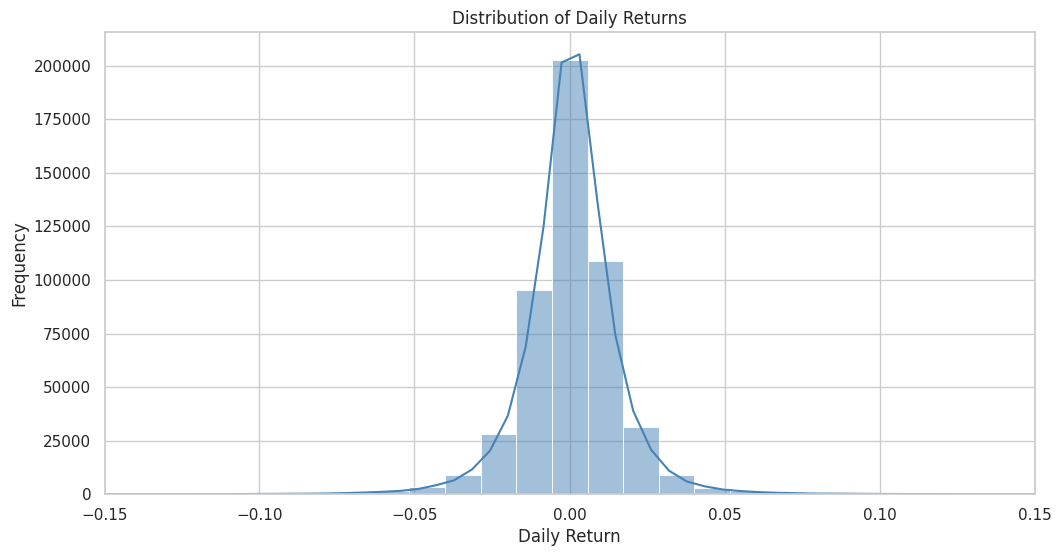

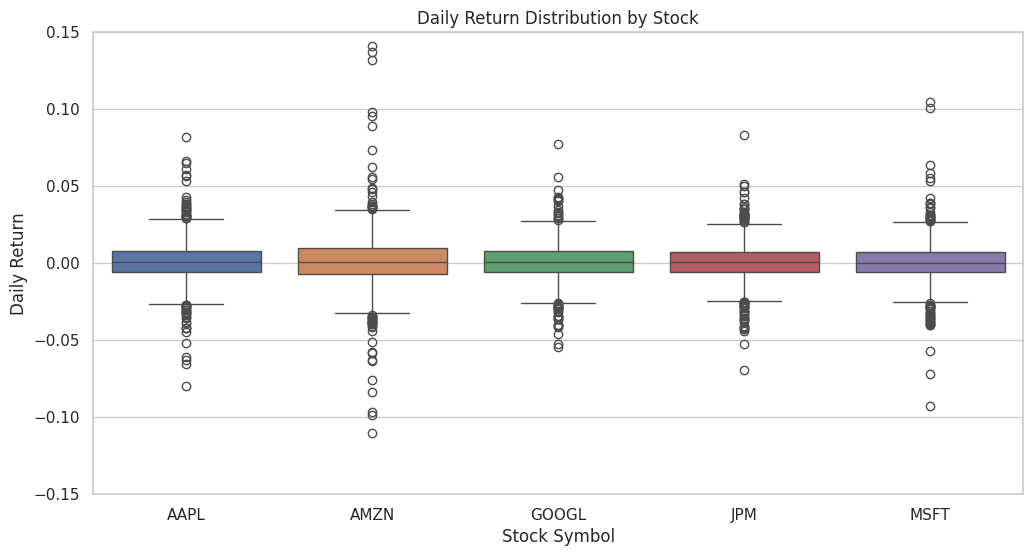

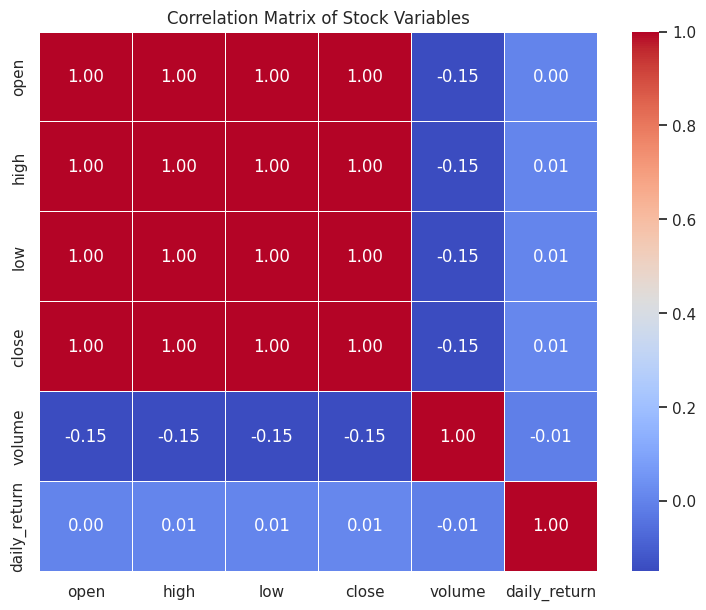

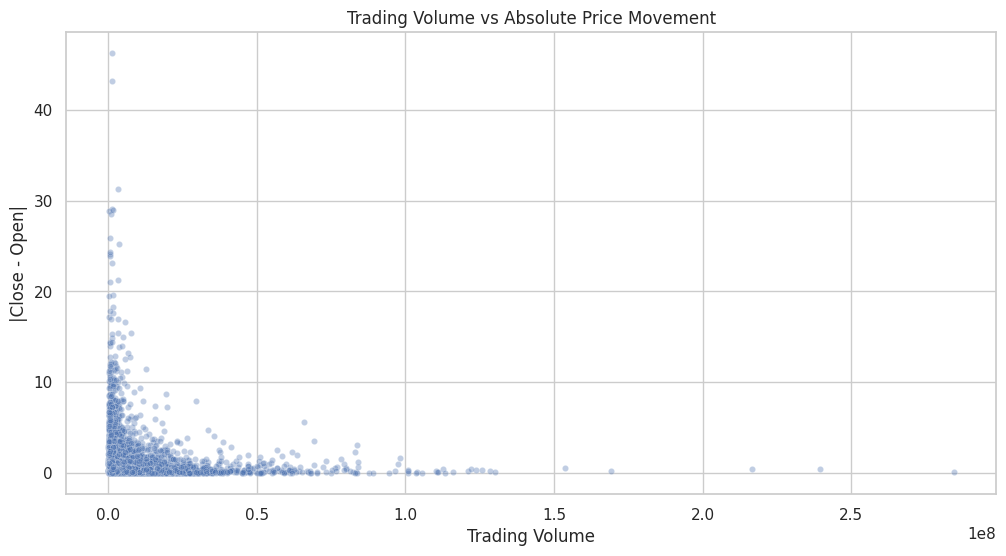

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

requested_stocks = ["AAPL", "MSFT", "AMZN", "GOOGL", "JPM"]
available_stocks = [
    stock for stock in requested_stocks
    if stock in df_eda["symbol"].unique()]

print("Stocks used in charts:", available_stocks)

plt.figure(figsize=(14, 6))

for stock in available_stocks:
    stock_data = df_eda[df_eda["symbol"] == stock]
    plt.plot(stock_data["date"], stock_data["close"], label=stock)

plt.title("Closing Price Trends of Selected Stocks")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.show()


plt.figure(figsize=(12, 6))

sns.histplot(
    df_eda["daily_return"].dropna(),
    bins=100,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.xlim(-0.15, 0.15)
plt.show()


boxplot_data = df_eda[df_eda["symbol"].isin(available_stocks)]

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=boxplot_data,
    x="symbol",
    y="daily_return",
    hue="symbol",
    legend=False
)

plt.title("Daily Return Distribution by Stock")
plt.xlabel("Stock Symbol")
plt.ylabel("Daily Return")
plt.ylim(-0.15, 0.15)
plt.show()


numeric_columns = [
    "open", "high", "low",
    "close", "volume", "daily_return"
]

correlation_matrix = df_eda[numeric_columns].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Stock Variables")
plt.show()


df_eda["absolute_price_change"] = (
    df_eda["close"] - df_eda["open"]
).abs()


scatter_data = df_eda.sample(
    n=min(20000, len(df_eda)),
    random_state=42
)

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=scatter_data,
    x="volume",
    y="absolute_price_change",
    alpha=0.35,
    s=20
)

plt.title("Trading Volume vs Absolute Price Movement")
plt.xlabel("Trading Volume")
plt.ylabel("|Close - Open|")
plt.show()

**Rolling Average, Volume Trend aur Candlestick Chart.**

Selected stock: AAPL


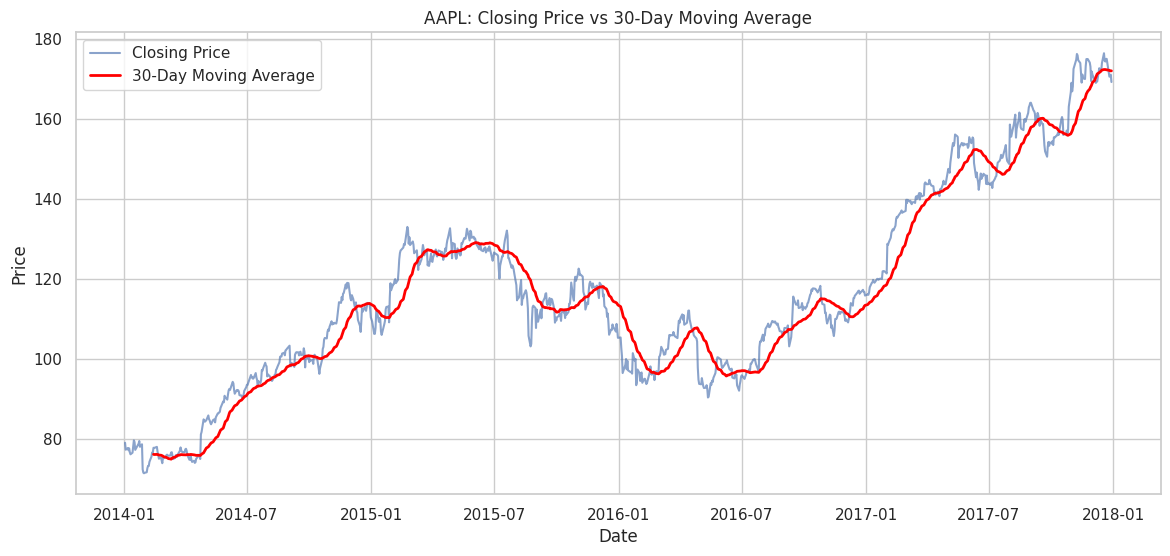

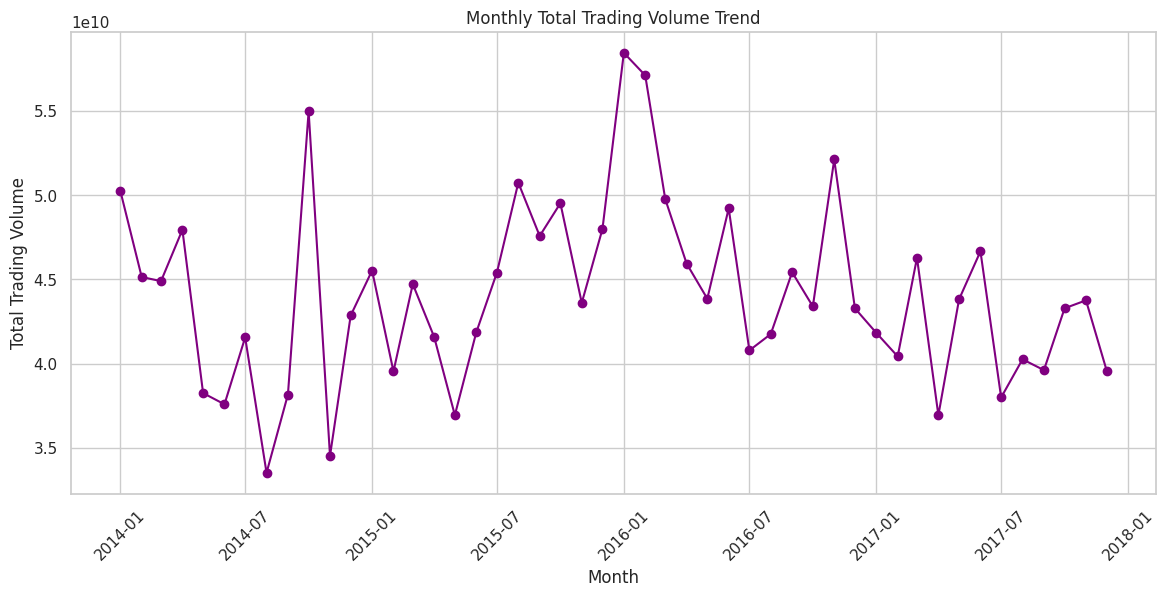

In [38]:
chart_stock = "AAPL" if "AAPL" in df_eda["symbol"].unique() else available_stocks[0]

stock_chart_data = df_eda[
    df_eda["symbol"] == chart_stock
].copy()

print("Selected stock:", chart_stock)


plt.figure(figsize=(14, 6))

plt.plot(
    stock_chart_data["date"],
    stock_chart_data["close"],
    label="Closing Price",
    alpha=0.65
)

plt.plot(
    stock_chart_data["date"],
    stock_chart_data["moving_average_30d"],
    label="30-Day Moving Average",
    linewidth=2,
    color="red"
)

plt.title(f"{chart_stock}: Closing Price vs 30-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


monthly_volume_chart = (
    df_eda.groupby("month")["volume"]
    .sum()
    .reset_index()
)

monthly_volume_chart["month"] = (
    monthly_volume_chart["month"].dt.to_timestamp()
)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_volume_chart["month"],
    monthly_volume_chart["volume"],
    marker="o",
    color="purple"
)

plt.title("Monthly Total Trading Volume Trend")
plt.xlabel("Month")
plt.ylabel("Total Trading Volume")
plt.xticks(rotation=45)
plt.show()

import plotly.graph_objects as go

fig = go.Figure(
    data=[
        go.Candlestick(
            x=stock_chart_data["date"],
            open=stock_chart_data["open"],
            high=stock_chart_data["high"],
            low=stock_chart_data["low"],
            close=stock_chart_data["close"],
            name=chart_stock
        )
    ]
)

fig.update_layout(
    title=f"{chart_stock} Candlestick Chart",
    xaxis_title="Date",
    yaxis_title="Price",
    xaxis_rangeslider_visible=False,
    template="plotly_white",
    height=600
)

fig.show()

**Feature Engineering.**

In [39]:
df_features = (
    df_clean.copy()
    .sort_values(["symbol", "date"])
    .reset_index(drop=True)
)

df_features["previous_day_close"] = (
    df_features.groupby("symbol")["close"]
    .shift(1)
)


df_features["daily_return"] = (
    (df_features["close"] - df_features["previous_day_close"])
    / df_features["previous_day_close"]
)


df_features["moving_average_7d"] = (
    df_features.groupby("symbol")["close"]
    .transform(lambda x: x.rolling(window=7, min_periods=7).mean())
)

df_features["moving_average_30d"] = (
    df_features.groupby("symbol")["close"]
    .transform(lambda x: x.rolling(window=30, min_periods=30).mean())
)


df_features["ema_30d"] = (
    df_features.groupby("symbol")["close"]
    .transform(lambda x: x.ewm(span=30, adjust=False).mean())
)


df_features["volatility_30d"] = (
    df_features.groupby("symbol")["daily_return"]
    .transform(lambda x: x.rolling(window=30, min_periods=30).std())
)


df_features["price_difference"] = (
    df_features["close"] - df_features["previous_day_close"]
)

df_features["high_low_spread"] = (
    df_features["high"] - df_features["low"]
)

df_features["open_close_difference"] = (
    df_features["close"] - df_features["open"]
)


df_features["close_lag_1d"] = (
    df_features.groupby("symbol")["close"]
    .shift(1)
)

df_features["close_lag_7d"] = (
    df_features.groupby("symbol")["close"]
    .shift(7)
)


df_features["rolling_mean_30d"] = (
    df_features.groupby("symbol")["close"]
    .transform(lambda x: x.rolling(window=30, min_periods=30).mean())
)

df_features["rolling_max_30d"] = (
    df_features.groupby("symbol")["close"]
    .transform(lambda x: x.rolling(window=30, min_periods=30).max())
)

df_features["rolling_min_30d"] = (
    df_features.groupby("symbol")["close"]
    .transform(lambda x: x.rolling(window=30, min_periods=30).min())
)


feature_columns = [
    "previous_day_close", "daily_return",
    "moving_average_7d", "moving_average_30d", "ema_30d",
    "volatility_30d", "price_difference", "high_low_spread",
    "open_close_difference", "close_lag_1d", "close_lag_7d",
    "rolling_mean_30d", "rolling_max_30d", "rolling_min_30d"
]

print("Newly created features:")
print(feature_columns)

print("\nMissing values in feature columns:")
print(df_features[feature_columns].isnull().sum())


sample_symbol = "AAPL" if "AAPL" in df_features["symbol"].unique() else df_features["symbol"].iloc[0]

display(
    df_features[df_features["symbol"] == sample_symbol]
    [["symbol", "date", "close"] + feature_columns].head(35))

Newly created features:
['previous_day_close', 'daily_return', 'moving_average_7d', 'moving_average_30d', 'ema_30d', 'volatility_30d', 'price_difference', 'high_low_spread', 'open_close_difference', 'close_lag_1d', 'close_lag_7d', 'rolling_mean_30d', 'rolling_max_30d', 'rolling_min_30d']

Missing values in feature columns:
previous_day_close         505
daily_return               505
moving_average_7d         3030
moving_average_30d       14634
ema_30d                      0
volatility_30d           15138
price_difference           505
high_low_spread              0
open_close_difference        0
close_lag_1d               505
close_lag_7d              3535
rolling_mean_30d         14634
rolling_max_30d          14634
rolling_min_30d          14634
dtype: int64


,symbol,date,close,previous_day_close,daily_return,moving_average_7d,moving_average_30d,ema_30d,volatility_30d,price_difference,high_low_spread,open_close_difference,close_lag_1d,close_lag_7d,rolling_mean_30d,rolling_max_30d,rolling_min_30d
3021,AAPL,2014-01-02,79.0185,NaN,NaN,NaN,NaN,79.018500,NaN,NaN,0.7155,-0.3643,NaN,NaN,NaN,NaN,NaN
3022,AAPL,2014-01-03,77.2828,79.0185,-0.021966,NaN,NaN,78.906519,NaN,-1.7357,1.8957,-1.6971,79.0185,NaN,NaN,NaN,NaN
3023,AAPL,2014-01-06,77.7042,77.2828,0.005453,NaN,NaN,78.828950,NaN,0.4214,1.8857,0.9257,77.2828,NaN,NaN,NaN,NaN
3024,AAPL,2014-01-07,77.1481,77.7042,-0.007157,NaN,NaN,78.720508,NaN,-0.5561,1.1478,-0.6118,77.7042,NaN,NaN,NaN,NaN
3025,AAPL,2014-01-08,77.6371,77.1481,0.006338,NaN,NaN,78.650611,NaN,0.4890,0.9815,0.6643,77.1481,NaN,NaN,NaN,NaN
3026,AAPL,2014-01-09,76.6455,77.6371,-0.012772,NaN,NaN,78.521249,NaN,-0.9916,1.6443,-1.4687,77.6371,NaN,NaN,NaN,NaN
3027,AAPL,2014-01-10,76.1342,76.6455,-0.006671,77.367200,NaN,78.367246,NaN,-0.5113,1.3843,-0.9843,76.6455,NaN,NaN,NaN,NaN
3028,AAPL,2014-01-13,76.5328,76.1342,0.005235,77.012100,NaN,78.248895,NaN,0.3986,1.8028,0.8314,76.1342,79.0185,NaN,NaN,NaN
3029,AAPL,2014-01-14,78.0556,76.5328,0.019897,77.122500,NaN,78.236424,NaN,1.5228,1.2957,1.1671,76.5328,77.2828,NaN,NaN,NaN
3030,AAPL,2014-01-15,79.6228,78.0556,0.020078,77.396586,NaN,78.325868,NaN,1.5672,1.2200,0.5486,78.0556,77.7042,NaN,NaN,NaN


**Statistical Analysis.**

In [40]:
from scipy import stats

df_stats = df_features.dropna(subset=["daily_return"]).copy()

stat_columns = [
    "open", "high", "low", "close",
    "volume", "daily_return",
    "volatility_30d"
]

correlation_matrix = df_stats[stat_columns].corr()

print("Correlation Matrix:")
display(correlation_matrix)


covariance_matrix = df_stats[stat_columns].cov()

print("\nCovariance Matrix:")
display(covariance_matrix)


df_stats["daily_return_zscore"] = stats.zscore(
    df_stats["daily_return"]
)


zscore_outliers = df_stats[
    df_stats["daily_return_zscore"].abs() > 3
]

print("\nNumber of Z-score outliers:", len(zscore_outliers))

display(
    zscore_outliers[
        ["symbol", "date", "close", "daily_return", "daily_return_zscore"]
    ]
    .sort_values("daily_return_zscore", key=abs, ascending=False)
    .head(10)
)


Q1 = df_stats["daily_return"].quantile(0.25)
Q3 = df_stats["daily_return"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

iqr_outliers = df_stats[
    (df_stats["daily_return"] < lower_limit) |
    (df_stats["daily_return"] > upper_limit)
]

print("\nIQR lower limit:", round(lower_limit, 4))
print("IQR upper limit:", round(upper_limit, 4))
print("Number of IQR outliers:", len(iqr_outliers))


daily_returns = df_stats["daily_return"]

print("\nDaily Return Distribution:")
print(daily_returns.describe())


print("\nSkewness:", round(daily_returns.skew(), 4))
print("Kurtosis:", round(daily_returns.kurt(), 4))


normality_sample = daily_returns.sample(
    n=min(50000, len(daily_returns)),
    random_state=42
)

normality_statistic, normality_p_value = stats.normaltest(normality_sample)

print("\nNormality test statistic:", round(normality_statistic, 4))
print("Normality test p-value:", normality_p_value)

if normality_p_value < 0.05:
    print("Conclusion: Daily returns are NOT normally distributed.")
else:
    print("Conclusion: Daily returns appear normally distributed.")

Correlation Matrix:


,open,high,low,close,volume,daily_return,volatility_30d
open,1.000000,0.999941,0.999928,0.999876,-0.148757,0.001832,-0.072155
high,0.999941,1.000000,0.999905,0.999938,-0.148377,0.005661,-0.070294
low,0.999928,0.999905,1.000000,0.999941,-0.149318,0.006181,-0.074079
close,0.999876,0.999938,0.999941,1.000000,-0.148873,0.009877,-0.072086
volume,-0.148757,-0.148377,-0.149318,-0.148873,1.000000,-0.010667,0.174807
daily_return,0.001832,0.005661,0.006181,0.009877,-0.010667,1.000000,0.013742
volatility_30d,-0.072155,-0.070294,-0.074079,-0.072086,0.174807,0.013742,1.000000



Covariance Matrix:


,open,high,low,close,volume,daily_return,volatility_30d
open,1.030095e+04,1.038575e+04,1.020887e+04,1.029973e+04,-1.242700e+08,0.003013,-0.053418
high,1.038575e+04,1.047249e+04,1.029330e+04,1.038579e+04,-1.249810e+08,0.009389,-0.052469
low,1.020887e+04,1.029330e+04,1.011908e+04,1.020908e+04,-1.236328e+08,0.010076,-0.054358
close,1.029973e+04,1.038579e+04,1.020908e+04,1.030108e+04,-1.243680e+08,0.016247,-0.053366
volume,-1.242700e+08,-1.249810e+08,-1.236328e+08,-1.243680e+08,6.774893e+13,-1422.959326,10330.641849
daily_return,3.013266e-03,9.389073e-03,1.007643e-02,1.624664e-02,-1.422959e+03,0.000263,0.000002
volatility_30d,-5.341757e-02,-5.246863e-02,-5.435756e-02,-5.336615e-02,1.033064e+04,0.000002,0.000053



Number of Z-score outliers: 7048


,symbol,date,close,daily_return,daily_return_zscore
329890,NI,2015-07-02,16.990,-0.626183,-38.664410
150292,EBAY,2015-07-20,28.570,-0.569015,-35.137108
32804,AMD,2016-04-22,3.990,0.522901,32.235149
136691,DISCK,2014-08-07,39.780,-0.510219,-31.509352
135684,DISCA,2014-08-07,40.975,-0.506444,-31.276435
60813,BAX,2015-07-01,38.860,-0.444301,-27.442165
468245,VRTX,2014-06-24,93.530,0.404144,24.907712
341523,NWL,2017-09-15,43.200,0.402142,24.784226
66596,BHGE,2017-07-05,37.250,-0.354196,-21.882545
479226,WMB,2016-02-08,11.160,-0.348131,-21.508346



IQR lower limit: -0.029
IQR upper limit: 0.0302
Number of IQR outliers: 28162

Daily Return Distribution:
count    496954.000000
mean          0.000459
std           0.016207
min          -0.626183
25%          -0.006814
50%           0.000581
75%           0.007995
max           0.522901
Name: daily_return, dtype: float64

Skewness: -0.3742
Kurtosis: 36.1757

Normality test statistic: 24477.834
Normality test p-value: 0.0
Conclusion: Daily returns are NOT normally distributed.


**Machine Learning Problem.**

This is a supervised regression problem. The objective is to predict the
next trading day's closing price for a selected stock using historical
price, volume, lag, moving-average, and volatility features.

- Problem Type: Regression
- Selected Stock: AAPL
- Target Variable: Next Day Closing Price
- Evaluation Strategy: Chronological train-validation-test split
- Metrics: MAE, MSE, RMSE, R² Score, and MAPE

In [41]:

model_stock = "AAPL" if "AAPL" in df_features["symbol"].unique() else df_features["symbol"].iloc[0]

model_df = (
    df_features[df_features["symbol"] == model_stock]
    .copy()
    .sort_values("date")
    .reset_index(drop=True)
)


model_df["target_next_day_close"] = model_df["close"].shift(-1)


model_features = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "previous_day_close",
    "daily_return",
    "moving_average_7d",
    "moving_average_30d",
    "ema_30d",
    "volatility_30d",
    "high_low_spread",
    "open_close_difference",
    "close_lag_7d",
    "rolling_max_30d",
    "rolling_min_30d"
]


model_df = model_df.dropna(
    subset=model_features + ["target_next_day_close"]
).reset_index(drop=True)


X = model_df[model_features]
y = model_df["target_next_day_close"]

print("Selected stock:", model_stock)
print("Model dataset shape:", model_df.shape)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

display(
    model_df[
        ["date", "close", "target_next_day_close"] + model_features[:4]
    ].head()
)

Selected stock: AAPL
Model dataset shape: (976, 22)
Feature matrix shape: (976, 16)
Target shape: (976,)


,date,close,target_next_day_close,open,high,low,close
0,2014-02-14,77.7128,77.9985,77.4956,77.9971,77.3156,77.7128
1,2014-02-18,77.9985,76.7671,77.9999,78.7413,77.9442,77.9985
2,2014-02-19,76.7671,75.8785,77.8214,78.1271,76.3356,76.7671
3,2014-02-20,75.8785,75.0356,76.1414,76.7142,75.5714,75.8785
4,2014-02-21,75.0356,75.3642,76.1132,76.3671,74.9428,75.0356


**Model Development.**

In [42]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

total_rows = len(model_df)

train_end = int(total_rows * 0.70)
validation_end = int(total_rows * 0.85)

X_train = X.iloc[:train_end]
X_validation = X.iloc[train_end:validation_end]
X_test = X.iloc[validation_end:]

y_train = y.iloc[:train_end]
y_validation = y.iloc[train_end:validation_end]
y_test = y.iloc[validation_end:]

print("Train data:", X_train.shape)
print("Validation data:", X_validation.shape)
print("Test data:", X_test.shape)


models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

trained_models = {}
validation_predictions = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)

    trained_models[model_name] = model
    validation_predictions[model_name] = model.predict(X_validation)

    print(f"{model_name} trained successfully.")

Train data: (683, 16)
Validation data: (146, 16)
Test data: (147, 16)
Linear Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


**Model Evaluation.**

Validation Performance of All Models:


,Model,MAE,MSE,RMSE,R2 Score,MAPE (%)
0,Linear Regression,0.948688,2.020417,1.421414,0.991234,0.729400
1,Gradient Boosting,8.257310,137.044366,11.706595,0.405429,5.727840
2,Random Forest,8.323382,137.519311,11.726863,0.403368,5.781739
3,Decision Tree,10.716822,205.523586,14.336094,0.108329,7.519528


Best model based on Validation RMSE: Linear Regression

Final Test Performance of Best Model:
MAE: 1.4536
MSE: 3.9302
RMSE: 1.9825
R² Score: 0.9581
MAPE: 0.92 %


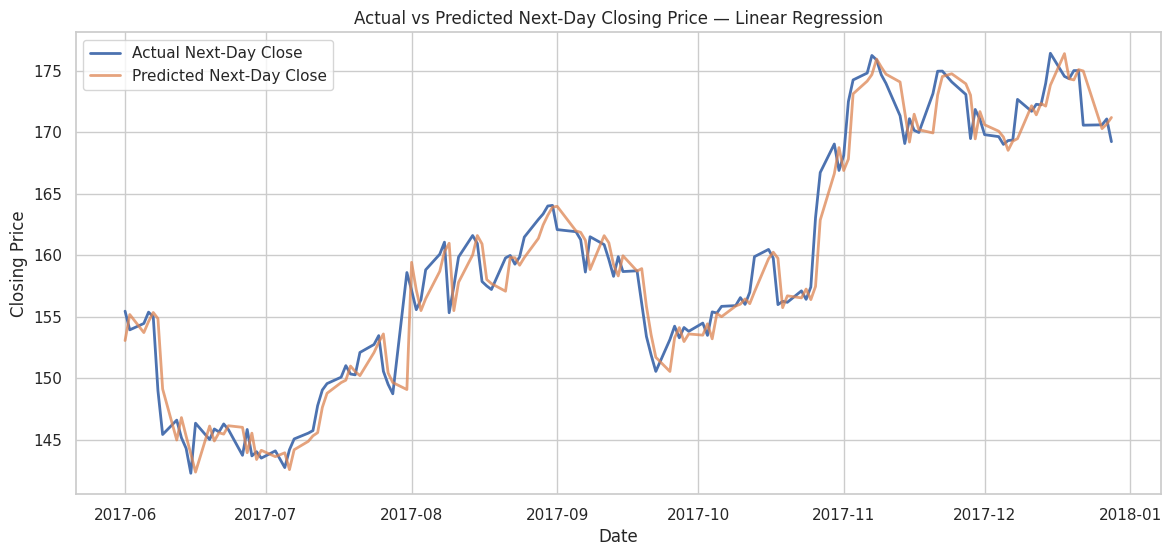

In [43]:

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)
from sklearn.base import clone

evaluation_results = []

for model_name, predictions in validation_predictions.items():

    mae = mean_absolute_error(y_validation, predictions)
    mse = mean_squared_error(y_validation, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_validation, predictions)
    mape = mean_absolute_percentage_error(y_validation, predictions) * 100

    evaluation_results.append({
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2,
        "MAPE (%)": mape
    })

# Summary table
results_df = pd.DataFrame(evaluation_results)
results_df = results_df.sort_values("RMSE").reset_index(drop=True)

print("Validation Performance of All Models:")
display(results_df)

best_model_name = results_df.loc[0, "Model"]
print("Best model based on Validation RMSE:", best_model_name)


X_train_validation = pd.concat([X_train, X_validation])
y_train_validation = pd.concat([y_train, y_validation])

best_model = clone(models[best_model_name])
best_model.fit(X_train_validation, y_train_validation)

#  Final Test Set evaluation
test_predictions = best_model.predict(X_test)

test_mae = mean_absolute_error(y_test, test_predictions)
test_mse = mean_squared_error(y_test, test_predictions)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, test_predictions)
test_mape = mean_absolute_percentage_error(y_test, test_predictions) * 100

print("\nFinal Test Performance of Best Model:")
print("MAE:", round(test_mae, 4))
print("MSE:", round(test_mse, 4))
print("RMSE:", round(test_rmse, 4))
print("R² Score:", round(test_r2, 4))
print("MAPE:", round(test_mape, 2), "%")

# Actual vs Predicted Closing Price chart
test_dates = model_df["date"].iloc[validation_end:]

plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test.values, label="Actual Next-Day Close", linewidth=2)
plt.plot(test_dates, test_predictions, label="Predicted Next-Day Close", linewidth=2, alpha=0.75)

plt.title(f"Actual vs Predicted Next-Day Closing Price — {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

**Feature Importance.**

Random Forest Feature Importance:


,Feature,Importance
0,close,0.651829
1,high,0.138332
2,low,0.108837
3,moving_average_7d,0.020513
4,open,0.019985
5,rolling_max_30d,0.017902
6,moving_average_30d,0.014822
7,previous_day_close,0.011097
8,ema_30d,0.009941
9,close_lag_7d,0.003863


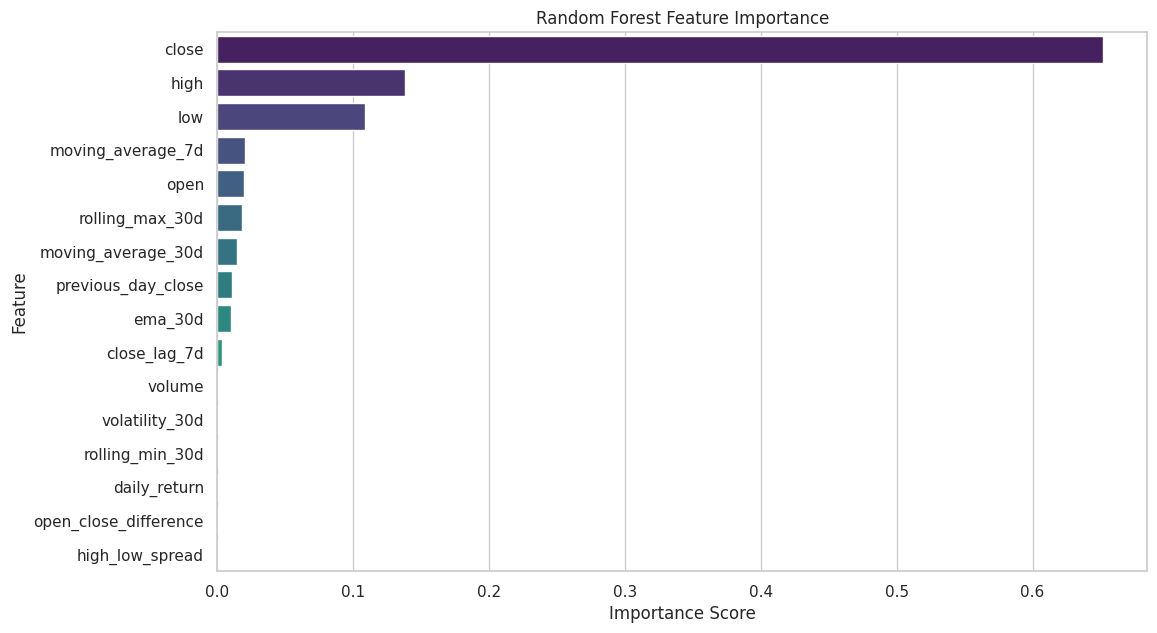


Permutation Feature Importance:


,Feature,Permutation Importance
0,close,3.402202e-01
1,low,3.325331e-01
2,high,1.500958e-01
3,open,5.807472e-02
4,previous_day_close,9.967792e-03
5,close_lag_7d,4.084031e-03
6,open_close_difference,2.133488e-03
7,daily_return,6.199133e-04
8,rolling_max_30d,2.716667e-05
9,rolling_min_30d,-2.486900e-15


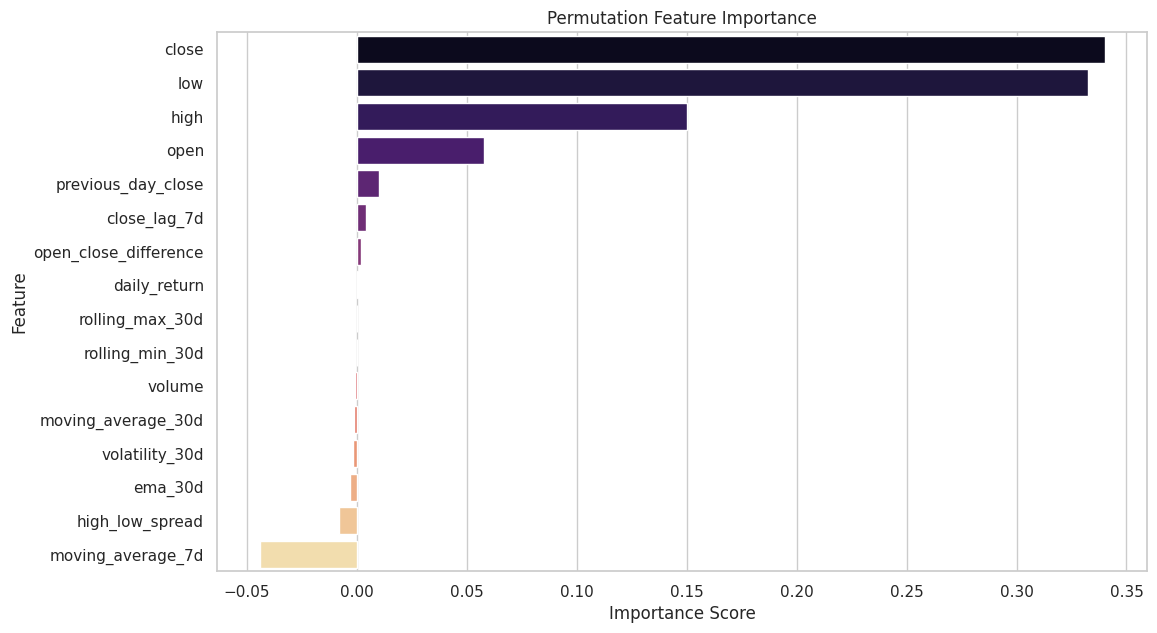

In [44]:
from sklearn.inspection import permutation_importance


rf_importance_model = clone(models["Random Forest"])

rf_importance_model.fit(
    X_train_validation,
    y_train_validation
)

#  Random Forest feature importance
feature_importance_df = pd.DataFrame({
    "Feature": model_features,
    "Importance": rf_importance_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("Random Forest Feature Importance:")
display(feature_importance_df)

# Feature importance bar chart
plt.figure(figsize=(12, 7))

sns.barplot(
    data=feature_importance_df,
    x="Importance",
    y="Feature",
    hue="Feature",
    legend=False,
    palette="viridis"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

#  Permutation Importance — Bonus
permutation_result = permutation_importance(
    rf_importance_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="neg_mean_absolute_error"
)

permutation_importance_df = pd.DataFrame({
    "Feature": model_features,
    "Permutation Importance": permutation_result.importances_mean
})

permutation_importance_df = permutation_importance_df.sort_values(
    "Permutation Importance",
    ascending=False
).reset_index(drop=True)

print("\nPermutation Feature Importance:")
display(permutation_importance_df)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=permutation_importance_df,
    x="Permutation Importance",
    y="Feature",
    hue="Feature",
    legend=False,
    palette="magma"
)

plt.title("Permutation Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

**Time Series Analysis (Bonus).**

Time-series stock: AAPL
Date range: 2014-01-02 00:00:00 to 2017-12-29 00:00:00


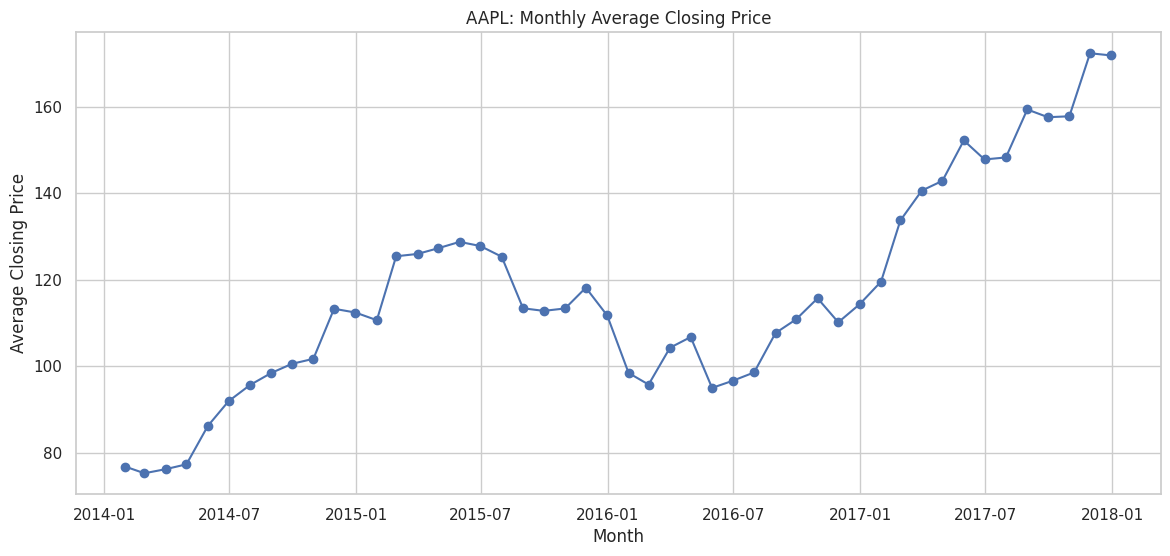

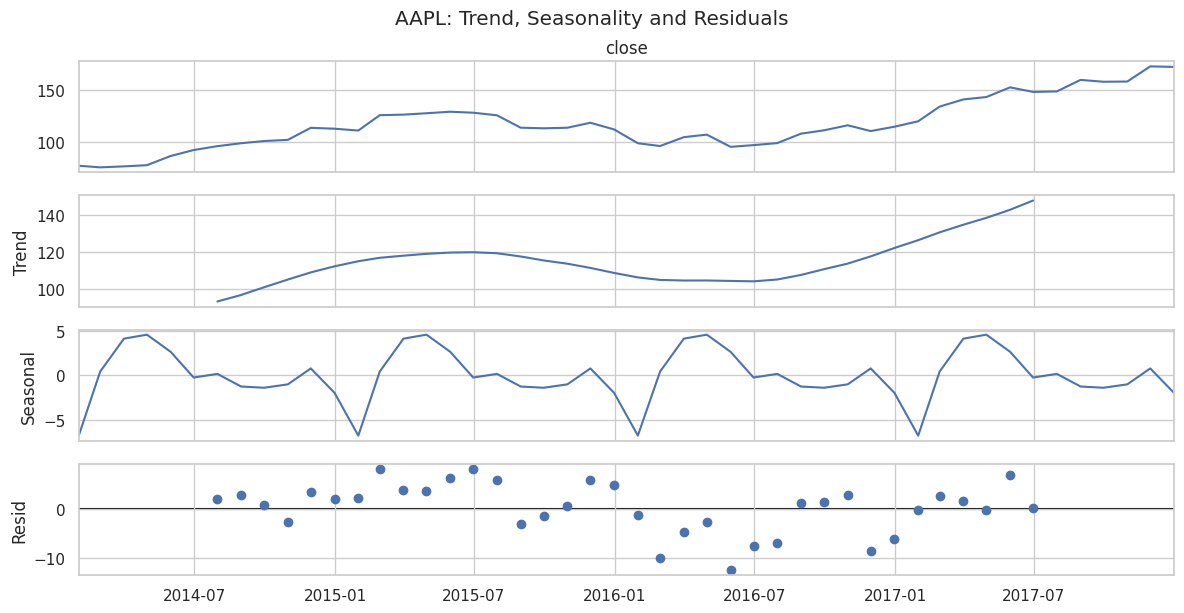

Next 30 Business-Day Forecast:


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the 

,Forecast Date,Predicted Close
0,2018-01-01,169.087306
1,2018-01-02,169.027537
2,2018-01-03,169.108869
3,2018-01-04,169.091223
4,2018-01-05,169.048889
5,2018-01-08,169.041300
6,2018-01-09,169.043370
7,2018-01-10,169.046565
8,2018-01-11,169.045646
9,2018-01-12,169.044415


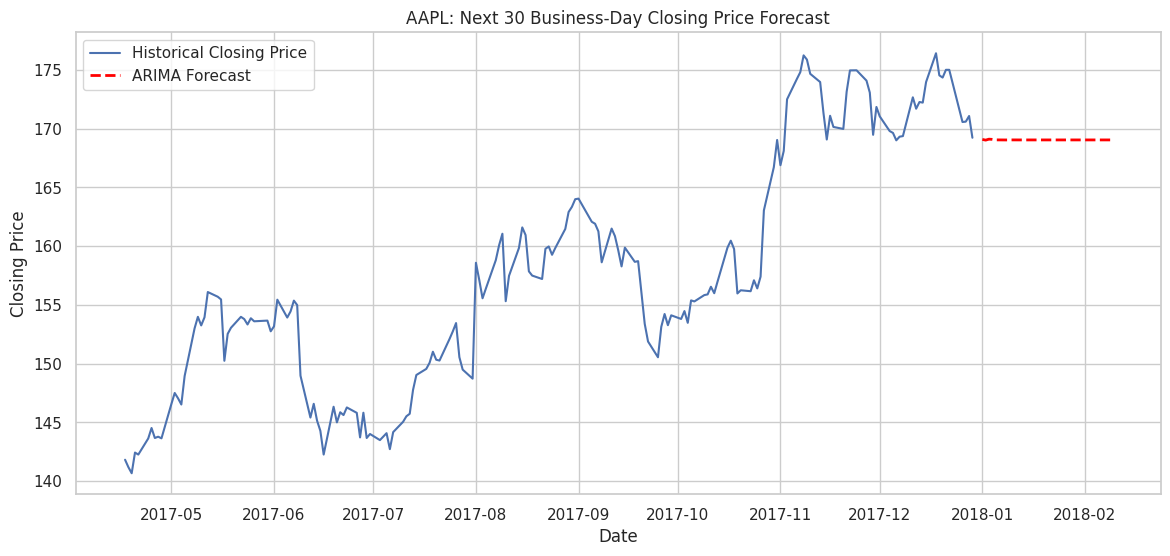

In [45]:

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

stock_ts = (
    df_clean[df_clean["symbol"] == model_stock]
    .copy()
    .sort_values("date")
    .set_index("date")
)

print("Time-series stock:", model_stock)
print("Date range:", stock_ts.index.min(), "to", stock_ts.index.max())

# ------------------------------------------
#  Monthly resampling
# ------------------------------------------
monthly_close = stock_ts["close"].resample("ME").mean()

plt.figure(figsize=(14, 6))
plt.plot(monthly_close.index, monthly_close.values, marker="o")

plt.title(f"{model_stock}: Monthly Average Closing Price")
plt.xlabel("Month")
plt.ylabel("Average Closing Price")
plt.show()

# ------------------------------------------
#  Trend decomposition
# ------------------------------------------
decomposition = seasonal_decompose(
    monthly_close,
    model="additive",
    period=12
)

decomposition.plot()
plt.suptitle(f"{model_stock}: Trend, Seasonality and Residuals", y=1.02)
plt.show()

# ------------------------------------------
#  ARIMA Forecast for next 30 business days
# ------------------------------------------
arima_model = ARIMA(
    stock_ts["close"],
    order=(5, 1, 0)
)

arima_fitted = arima_model.fit()

forecast_steps = 30
forecast_values = arima_fitted.forecast(steps=forecast_steps)

forecast_dates = pd.bdate_range(
    start=stock_ts.index.max() + pd.Timedelta(days=1),
    periods=forecast_steps
)

forecast_df = pd.DataFrame({
    "Forecast Date": forecast_dates,
    "Predicted Close": forecast_values.values
})

print("Next 30 Business-Day Forecast:")
display(forecast_df)

# Historical price + forecast chart
plt.figure(figsize=(14, 6))

# Recent 180 trading days
plt.plot(
    stock_ts.index[-180:],
    stock_ts["close"].iloc[-180:],
    label="Historical Closing Price"
)

plt.plot(
    forecast_dates,
    forecast_values.values,
    label="ARIMA Forecast",
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title(f"{model_stock}: Next 30 Business-Day Closing Price Forecast")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

**Business Insights Report.**

In [46]:

# Basic market facts
start_date = df_clean["date"].min().date()
end_date = df_clean["date"].max().date()
total_companies = df_clean["symbol"].nunique()
total_days = df_clean["date"].nunique()
total_rows = len(df_clean)

highest_close_row = df_clean.loc[df_clean["close"].idxmax()]
lowest_close_row = df_clean.loc[df_clean["close"].idxmin()]

# Company total-return analysis
stock_performance = (
    df_clean.groupby("symbol")
    .agg(
        first_close=("close", "first"),
        last_close=("close", "last"),
        average_close=("close", "mean"),
        total_volume=("volume", "sum")
    )
)

stock_performance["total_return_pct"] = (
    (stock_performance["last_close"] / stock_performance["first_close"]) - 1
) * 100

best_return_stock = stock_performance["total_return_pct"].idxmax()
worst_return_stock = stock_performance["total_return_pct"].idxmin()

# Volatility analysis
volatility_by_stock = (
    df_features.groupby("symbol")["daily_return"]
    .std()
    .sort_values()
)

least_volatile_stock = volatility_by_stock.index[0]
most_volatile_stock = volatility_by_stock.index[-1]

# Volume and average price
highest_volume_stock = stock_performance["total_volume"].idxmax()
highest_average_price_stock = stock_performance["average_close"].idxmax()

# Time trends
df_insights = df_features.copy()
df_insights["month"] = df_insights["date"].dt.to_period("M")
df_insights["year"] = df_insights["date"].dt.year

monthly_returns = df_insights.groupby("month")["daily_return"].mean()
yearly_returns = df_insights.groupby("year")["daily_return"].mean()

best_month = monthly_returns.idxmax()
worst_month = monthly_returns.idxmin()
best_year = yearly_returns.idxmax()
worst_year = yearly_returns.idxmin()

# Price movement and volume relation
df_insights["absolute_price_change"] = (
    df_insights["close"] - df_insights["open"]
).abs()

volume_price_correlation = df_insights[
    ["volume", "absolute_price_change"]
].corr().iloc[0, 1]

# Extreme daily-return information
highest_daily_return_row = df_insights.loc[
    df_insights["daily_return"].idxmax()
]

lowest_daily_return_row = df_insights.loc[
    df_insights["daily_return"].idxmin()
]

# Abnormal return insights
abnormal_return_count = len(zscore_outliers)
most_abnormal_stock = zscore_outliers["symbol"].value_counts().idxmax()

# Forecast insight
last_actual_close = stock_ts["close"].iloc[-1]
last_forecast_close = forecast_df["Predicted Close"].iloc[-1]
forecast_change_pct = (
    (last_forecast_close / last_actual_close) - 1
) * 100

# Top predictive feature
top_feature = feature_importance_df.iloc[0]["Feature"]
top_feature_score = feature_importance_df.iloc[0]["Importance"]

# Create 25 business insights
business_insights = [
    {
        "Observation": f"The cleaned dataset contains {total_rows:,} records for {total_companies} companies.",
        "Business Impact": "A large dataset supports reliable cross-company market analysis.",
        "Recommendation": "Use this dataset as the core historical source for research and modelling."
    },
    {
        "Observation": f"The analysis period is from {start_date} to {end_date}, covering {total_days} trading days.",
        "Business Impact": "The data captures multiple years of market behaviour.",
        "Recommendation": "Compare findings across yearly and quarterly market periods."
    },
    {
        "Observation": f"The highest closing price was {highest_close_row['close']:.2f} for {highest_close_row['symbol']} on {highest_close_row['date'].date()}.",
        "Business Impact": "High share prices may indicate strong historical valuation or growth.",
        "Recommendation": "Study the company's returns rather than price level alone."
    },
    {
        "Observation": f"The lowest closing price was {lowest_close_row['close']:.2f} for {lowest_close_row['symbol']} on {lowest_close_row['date'].date()}.",
        "Business Impact": "Low-priced stocks can have higher perceived risk or different price scales.",
        "Recommendation": "Assess return and volatility before considering low-priced stocks."
    },
    {
        "Observation": f"{best_return_stock} delivered the highest total return: {stock_performance.loc[best_return_stock, 'total_return_pct']:.2f}%.",
        "Business Impact": "This stock was one of the strongest historical performers.",
        "Recommendation": "Include it in a high-performance stock watchlist."
    },
    {
        "Observation": f"{worst_return_stock} delivered the lowest total return: {stock_performance.loc[worst_return_stock, 'total_return_pct']:.2f}%.",
        "Business Impact": "This stock underperformed during the study period.",
        "Recommendation": "Investigate risks and avoid relying only on past price levels."
    },
    {
        "Observation": f"{most_volatile_stock} was the most volatile stock based on daily-return standard deviation.",
        "Business Impact": "Higher volatility means larger potential gains and losses.",
        "Recommendation": "Use position-size limits and risk controls for highly volatile stocks."
    },
    {
        "Observation": f"{least_volatile_stock} was the least volatile stock in the dataset.",
        "Business Impact": "Lower volatility can support more stable portfolio allocation.",
        "Recommendation": "Consider low-volatility stocks for defensive portfolio strategies."
    },
    {
        "Observation": f"{highest_volume_stock} had the highest cumulative trading volume.",
        "Business Impact": "High volume usually indicates stronger liquidity and easier trade execution.",
        "Recommendation": "Prefer liquid stocks when reducing transaction-cost and execution risk."
    },
    {
        "Observation": f"{highest_average_price_stock} had the highest average closing price.",
        "Business Impact": "Price level shows market valuation scale, not necessarily investment quality.",
        "Recommendation": "Compare price with returns, volatility, and business fundamentals."
    },
    {
        "Observation": f"Volume and absolute intraday price movement had a correlation of {volume_price_correlation:.3f}.",
        "Business Impact": "Trading activity can be associated with stronger price movements.",
        "Recommendation": "Use volume as a supporting signal, not as a standalone trading rule."
    },
    {
        "Observation": f"The strongest average daily-return month was {best_month}.",
        "Business Impact": "This period showed relatively positive market performance.",
        "Recommendation": "Investigate market events or sector drivers behind the movement."
    },
    {
        "Observation": f"The weakest average daily-return month was {worst_month}.",
        "Business Impact": "This period reflected relatively weak market conditions.",
        "Recommendation": "Review downside-risk behaviour during weak market periods."
    },
    {
        "Observation": f"The best yearly average daily-return performance occurred in {best_year}.",
        "Business Impact": "This year had relatively favourable average market movement.",
        "Recommendation": "Use yearly comparisons when designing long-term investment strategies."
    },
    {
        "Observation": f"The weakest yearly average daily-return performance occurred in {worst_year}.",
        "Business Impact": "This year may contain higher market stress or lower growth conditions.",
        "Recommendation": "Stress-test portfolio strategies using weaker historical years."
    },
    {
        "Observation": f"The largest one-day positive return was {highest_daily_return_row['daily_return'] * 100:.2f}% for {highest_daily_return_row['symbol']}.",
        "Business Impact": "Extreme upward movement can indicate news-driven or abnormal activity.",
        "Recommendation": "Validate extreme moves with company news and volume information."
    },
    {
        "Observation": f"The largest one-day negative return was {lowest_daily_return_row['daily_return'] * 100:.2f}% for {lowest_daily_return_row['symbol']}.",
        "Business Impact": "Large negative movements represent important downside-risk events.",
        "Recommendation": "Use stop-loss, diversification, and event-risk monitoring."
    },
    {
        "Observation": f"Z-score analysis identified {abnormal_return_count:,} abnormal daily-return observations.",
        "Business Impact": "The market contains statistically unusual price movements.",
        "Recommendation": "Flag abnormal returns for further event and risk analysis."
    },
    {
        "Observation": f"{most_abnormal_stock} had the most Z-score-based abnormal-return events.",
        "Business Impact": "The stock may be more sensitive to market or company-specific events.",
        "Recommendation": "Apply enhanced monitoring before including it in a conservative portfolio."
    },
    {
        "Observation": "The normality test rejected the assumption that daily returns are normally distributed.",
        "Business Impact": "Extreme returns occur more often than a simple normal model may expect.",
        "Recommendation": "Use risk methods that account for outliers and fat-tailed returns."
    },
    {
        "Observation": f"{best_model_name} was the best validation model based on lowest RMSE.",
        "Business Impact": "It produced the most accurate validation predictions among tested models.",
        "Recommendation": "Use this model as the primary baseline for price forecasting."
    },
    {
        "Observation": f"The best model achieved a test RMSE of {test_rmse:.4f}.",
        "Business Impact": "RMSE measures the typical size of prediction errors in price units.",
        "Recommendation": "Compare this error against the stock's normal daily price movement."
    },
    {
        "Observation": f"The best model achieved a test R² score of {test_r2:.4f} and MAPE of {test_mape:.2f}%.",
        "Business Impact": "These metrics show explanatory power and average percentage error.",
        "Recommendation": "Monitor these metrics regularly when retraining the model."
    },
    {
        "Observation": f"The most influential Random Forest feature was {top_feature} with importance {top_feature_score:.3f}.",
        "Business Impact": "Historical price-based features provide strong predictive information.",
        "Recommendation": "Keep top features in future model versions and monitor their stability."
    },
    {
        "Observation": f"The ARIMA forecast estimates a {forecast_change_pct:.2f}% change over the next 30 business days for {model_stock}.",
        "Business Impact": "The forecast gives a short-term directional scenario, not certainty.",
        "Recommendation": "Use the forecast with risk limits and additional fundamental analysis."
    }
]

business_insights_df = pd.DataFrame(business_insights)

print("Business Insights Report — 25 Insights")
display(business_insights_df)

Business Insights Report — 25 Insights


,Observation,Business Impact,Recommendation
0,"The cleaned dataset contains 497,459 records f...",A large dataset supports reliable cross-compan...,Use this dataset as the core historical source...
1,The analysis period is from 2014-01-02 to 2017...,The data captures multiple years of market beh...,Compare findings across yearly and quarterly m...
2,The highest closing price was 2049.00 for PCLN...,High share prices may indicate strong historic...,Study the company's returns rather than price ...
3,The lowest closing price was 1.59 for CHK on 2...,Low-priced stocks can have higher perceived ri...,Assess return and volatility before considerin...
4,NVDA delivered the highest total return: 1120....,This stock was one of the strongest historical...,Include it in a high-performance stock watchlist.
5,CHK delivered the lowest total return: -85.12%.,This stock underperformed during the study per...,Investigate risks and avoid relying only on pa...
6,CHK was the most volatile stock based on daily...,Higher volatility means larger potential gains...,Use position-size limits and risk controls for...
7,PEP was the least volatile stock in the dataset.,Lower volatility can support more stable portf...,Consider low-volatility stocks for defensive p...
8,BAC had the highest cumulative trading volume.,High volume usually indicates stronger liquidi...,Prefer liquid stocks when reducing transaction...
9,PCLN had the highest average closing price.,"Price level shows market valuation scale, not ...","Compare price with returns, volatility, and bu..."


**Code Documentation**

# S&P 500 Stock Market Analytics & Price Prediction

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Plotly, Scikit-learn, Statsmodels  
**Dataset:** S&P 500 Stock Prices (2014–2017)

## Project Workflow
1. Project Understanding
2. Data Loading and Exploration
3. Data Cleaning
4. Exploratory Data Analysis
5. Data Visualization
6. Feature Engineering
7. Statistical Analysis
8. Machine Learning Problem Definition
9. Model Development
10. Model Evaluation
11. Feature Importance
12. Time-Series Forecasting
13. Business Insights
14. Code Documentation

In [47]:
%%writefile README.md


Overwriting README.md


# S&P 500 Stock Market Analytics & Price Prediction

## Project Overview
This project analyzes historical S&P 500 stock-price data from 2014 to 2017.
It performs data cleaning, exploratory analysis, visualization, feature
engineering, statistical analysis, machine-learning regression, and ARIMA
time-series forecasting.

## Dataset
The dataset includes the following columns:

- symbol: Stock ticker symbol
- date: Trading date
- open: Opening price
- high: Highest price of the day
- low: Lowest price of the day
- close: Closing price
- volume: Number of traded shares

## Key Tasks Performed
- Loaded and explored stock-price data
- Handled missing values and invalid OHLC records
- Analyzed stock returns, volatility, trading volume, and market trends
- Created visualizations such as line charts, histograms, heatmaps, and candlestick charts
- Engineered lag, moving-average, volatility, and price-difference features
- Performed correlation, covariance, Z-score, IQR, skewness, kurtosis, and normality analysis
- Built Linear Regression, Decision Tree, Random Forest, and Gradient Boosting models
- Evaluated models using MAE, MSE, RMSE, R² Score, and MAPE
- Identified important predictive features using Random Forest and permutation importance
- Forecasted the next 30 business-day closing prices using ARIMA
- Generated business insights and recommendations

## How to Run
1. Upload `S&P 500 Stock Prices 2014-2017.csv` to Google Colab.
2. Run notebook cells in sequence from top to bottom.
3. Install required libraries using `requirements.txt` if working outside Google Colab.

## Project Structure
- `S&P500_Stock_Analysis.ipynb` — Main Jupyter Notebook
- `README.md` — Project documentation
- `requirements.txt` — Required Python libraries
- `S&P 500 Stock Prices 2014-2017.csv` — Input dataset

## Author
Financial Data Science Project
Phir requirements.txt banane ke liye ek aur Code cell:
%%writefile requirements.txt

pandas
numpy
matplotlib
seaborn
plotly
scikit-learn
scipy
statsmodels
jupyter

In [48]:
%%writefile requirements.txt

pandas
numpy
matplotlib
seaborn
plotly
scikit-learn
scipy
statsmodels
jupyter

Overwriting requirements.txt


In [49]:
from google.colab import files

files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Bonus Challenge 1: Top 10 Most Volatile Stocks.**

Top 10 Most Volatile Stocks:


,symbol,volatility_percent
0,CHK,4.554170
1,AMD,3.910169
2,FCX,3.698899
3,BHGE,3.661471
4,WMB,3.234744
5,MRO,3.216357
6,EVHC,2.955314
7,RRC,2.907283
8,INCY,2.856040
9,UA,2.843325


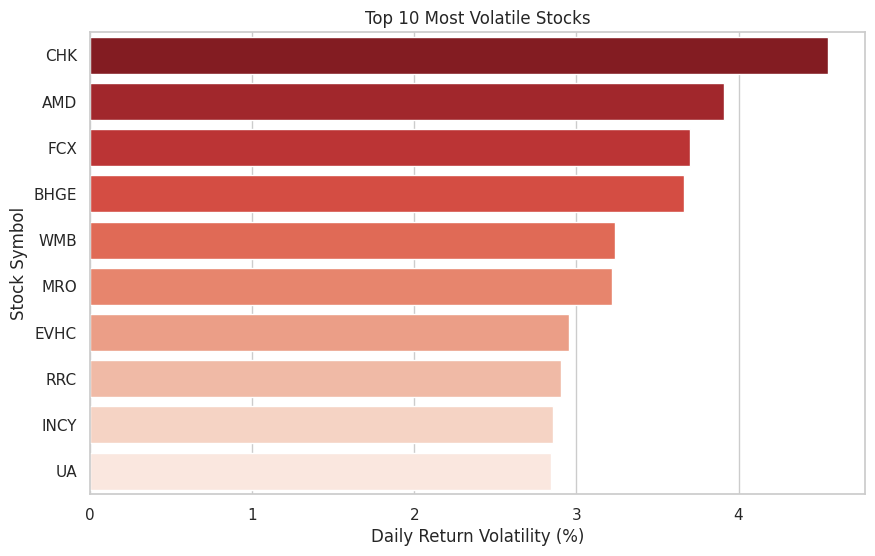

In [50]:
# Daily-return standard deviation se volatility calculate karna
top_10_volatile = (
    df_features.groupby("symbol")["daily_return"]
    .std()
    .mul(100)  # Percentage format
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="volatility_percent")
)

print("Top 10 Most Volatile Stocks:")
display(top_10_volatile)

# Visualization
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_volatile,
    x="volatility_percent",
    y="symbol",
    hue="symbol",
    legend=False,
    palette="Reds_r"
)

plt.title("Top 10 Most Volatile Stocks")
plt.xlabel("Daily Return Volatility (%)")
plt.ylabel("Stock Symbol")
plt.show()

**Bonus Challenge 2: Calculate 30-Day Moving Average for Every Stock.**

In [51]:
# Function to calculate 30-day moving average for every stock
def add_30_day_moving_average(data):
    data = data.copy()
    data = data.sort_values(["symbol", "date"]).reset_index(drop=True)

    data["moving_average_30d"] = (
        data.groupby("symbol")["close"]
        .transform(lambda x: x.rolling(window=30, min_periods=30).mean())
    )

    return data

challenge_2_df = add_30_day_moving_average(df_clean)

# Example result for one stock
sample_stock = "AAPL" if "AAPL" in challenge_2_df["symbol"].unique() else challenge_2_df["symbol"].iloc[0]

display(
    challenge_2_df[
        challenge_2_df["symbol"] == sample_stock
    ][["symbol", "date", "close", "moving_average_30d"]].head(35)
)

,symbol,date,close,moving_average_30d
3021,AAPL,2014-01-02,79.0185,NaN
3022,AAPL,2014-01-03,77.2828,NaN
3023,AAPL,2014-01-06,77.7042,NaN
3024,AAPL,2014-01-07,77.1481,NaN
3025,AAPL,2014-01-08,77.6371,NaN
3026,AAPL,2014-01-09,76.6455,NaN
3027,AAPL,2014-01-10,76.1342,NaN
3028,AAPL,2014-01-13,76.5328,NaN
3029,AAPL,2014-01-14,78.0556,NaN
3030,AAPL,2014-01-15,79.6228,NaN


**Bonus Challenge 3: Stocks whose closing price increased for 5 consecutive trading days.**

In [52]:
challenge_3_df = (
    df_clean.copy()
    .sort_values(["symbol", "date"])
    .reset_index(drop=True)
)


challenge_3_df["price_increased"] = (
    challenge_3_df.groupby("symbol")["close"]
    .diff()
    .gt(0)
)


challenge_3_df["streak_group"] = (
    challenge_3_df.groupby("symbol")["price_increased"]
    .transform(lambda x: (~x).cumsum())
)


challenge_3_df["consecutive_up_days"] = (
    challenge_3_df.groupby(["symbol", "streak_group"])["price_increased"]
    .cumsum()
)


five_day_streaks = challenge_3_df[
    challenge_3_df["consecutive_up_days"] == 5
][["symbol", "date", "close", "consecutive_up_days"]]

print("Number of five-day upward streaks:", len(five_day_streaks))
print("Unique stocks with at least one five-day upward streak:",
      five_day_streaks["symbol"].nunique())

display(five_day_streaks.head(20))

Number of five-day upward streaks: 8229
Unique stocks with at least one five-day upward streak: 504


,symbol,date,close,consecutive_up_days
12,A,2014-01-21,60.85,5
75,A,2014-04-22,54.97,5
90,A,2014-05-13,56.83,5
100,A,2014-05-28,57.11,5
108,A,2014-06-09,59.28,5
158,A,2014-08-19,58.56,5
462,A,2015-11-02,38.59,5
480,A,2015-11-27,41.97,5
547,A,2016-03-07,39.43,5
576,A,2016-04-18,41.31,5


**Bonus Challenge 4: Detect Abnormal Trading-Volume Spikes.**

In [53]:
# Data copy
challenge_4_df = df_clean.copy()

challenge_4_df["volume_zscore"] = (
    challenge_4_df.groupby("symbol")["volume"]
    .transform(lambda x: stats.zscore(x))
)

challenge_4_df["zscore_volume_spike"] = (
    challenge_4_df["volume_zscore"].abs() > 3
)

def iqr_upper_limit(volume_series):
    q1 = volume_series.quantile(0.25)
    q3 = volume_series.quantile(0.75)
    iqr = q3 - q1
    return q3 + (1.5 * iqr)

challenge_4_df["volume_iqr_upper_limit"] = (
    challenge_4_df.groupby("symbol")["volume"]
    .transform(iqr_upper_limit)
)

challenge_4_df["iqr_volume_spike"] = (
    challenge_4_df["volume"] > challenge_4_df["volume_iqr_upper_limit"]
)

challenge_4_df["abnormal_volume_spike"] = (
    challenge_4_df["zscore_volume_spike"] |
    challenge_4_df["iqr_volume_spike"]
)

volume_spikes = challenge_4_df[
    challenge_4_df["abnormal_volume_spike"]
][[
    "symbol", "date", "volume",
    "volume_zscore", "volume_iqr_upper_limit",
    "zscore_volume_spike", "iqr_volume_spike"
]]

print("Total abnormal volume spikes:", len(volume_spikes))
print("Stocks having volume spikes:", volume_spikes["symbol"].nunique())

display(
    volume_spikes
    .sort_values("volume_zscore", key=abs, ascending=False)
    .head(20)
)

Total abnormal volume spikes: 25451
Stocks having volume spikes: 504


,symbol,date,volume,volume_zscore,volume_iqr_upper_limit,zscore_volume_spike,iqr_volume_spike
164052,ESS,2014-04-01,18958032,30.395905,6.821860e+05,True,True
281878,LNT,2016-06-30,51880821,30.020578,2.226395e+06,True,True
143479,DRE,2017-07-25,86679197,29.477850,4.410107e+06,True,True
449539,UDR,2016-03-04,53725917,29.465246,2.905956e+06,True,True
191973,FRT,2016-01-29,14539241,29.426426,7.632702e+05,True,True
412248,SNPS,2017-03-15,30294553,28.807206,1.585067e+06,True,True
41150,ANSS,2017-06-16,17613441,28.727235,8.422008e+05,True,True
319182,MTD,2016-09-02,5345986,28.673888,3.331628e+05,True,True
470175,VZ,2014-02-24,618237630,28.355496,2.863112e+07,True,True
92212,CHD,2015-12-28,51368944,28.306556,2.894943e+06,True,True


**Bonus Challenge 5: Reusable Function to Calculate Daily Return.**

In [54]:
def calculate_daily_return(data, stock_symbol):
    """
    Calculates daily percentage return for a selected stock.

    Parameters:
        data (DataFrame): Clean stock-price dataset
        stock_symbol (str): Stock ticker, e.g. 'AAPL'

    Returns:
        DataFrame with date, close, and daily_return columns
    """

    stock_data = data[data["symbol"] == stock_symbol].copy()

    if stock_data.empty:
        print(f"Stock symbol '{stock_symbol}' was not found.")
        return None

    stock_data = stock_data.sort_values("date")

    stock_data["daily_return"] = (
        stock_data["close"].pct_change(fill_method=None) * 100
    )

    return stock_data[["symbol", "date", "close", "daily_return"]]


selected_stock_returns = calculate_daily_return(df_clean, "AAPL")

display(selected_stock_returns.head(10))

,symbol,date,close,daily_return
3021,AAPL,2014-01-02,79.0185,NaN
3022,AAPL,2014-01-03,77.2828,-2.196574
3023,AAPL,2014-01-06,77.7042,0.545270
3024,AAPL,2014-01-07,77.1481,-0.715663
3025,AAPL,2014-01-08,77.6371,0.633846
3026,AAPL,2014-01-09,76.6455,-1.277224
3027,AAPL,2014-01-10,76.1342,-0.667097
3028,AAPL,2014-01-13,76.5328,0.523549
3029,AAPL,2014-01-14,78.0556,1.989735
3030,AAPL,2014-01-15,79.6228,2.007800


**Bonus Challenge 6: Reusable Function to Plot Stock Trends.**

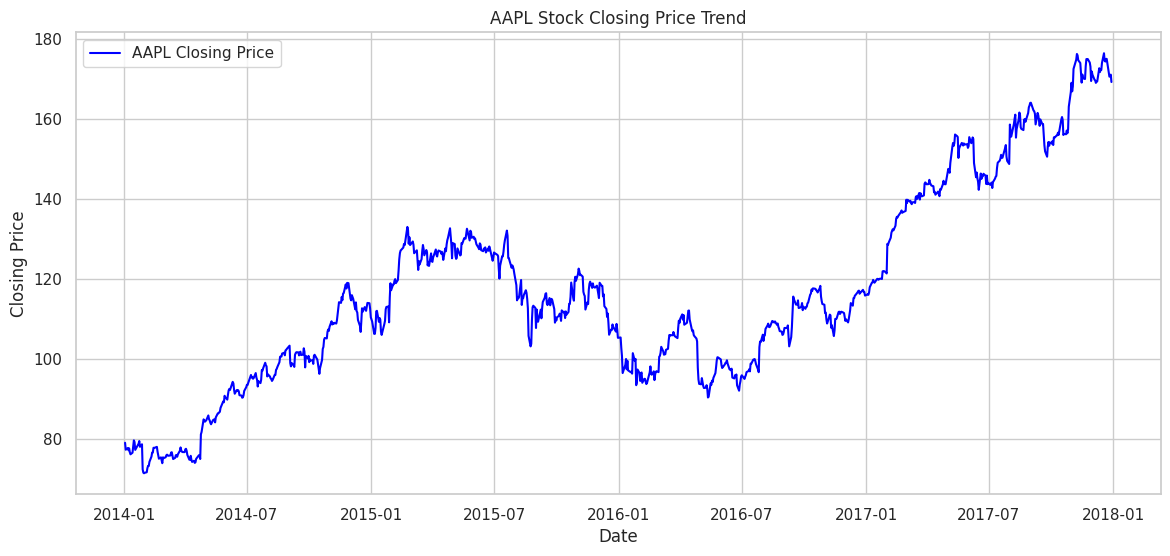

In [55]:
def plot_stock_trend(data, stock_symbol):
    """
    Plots closing-price trend for any selected stock.
    """

    stock_data = data[data["symbol"] == stock_symbol].copy()

    if stock_data.empty:
        print(f"Stock symbol '{stock_symbol}' was not found.")
        return

    stock_data = stock_data.sort_values("date")

    plt.figure(figsize=(14, 6))

    plt.plot(
        stock_data["date"],
        stock_data["close"],
        color="blue",
        label=f"{stock_symbol} Closing Price"
    )

    plt.title(f"{stock_symbol} Stock Closing Price Trend")
    plt.xlabel("Date")
    plt.ylabel("Closing Price")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_stock_trend(df_clean, "AAPL")

**Bonus Challenge 7: Compare Performance of Five Companies Over Time.**

Selected stocks: ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'JPM']


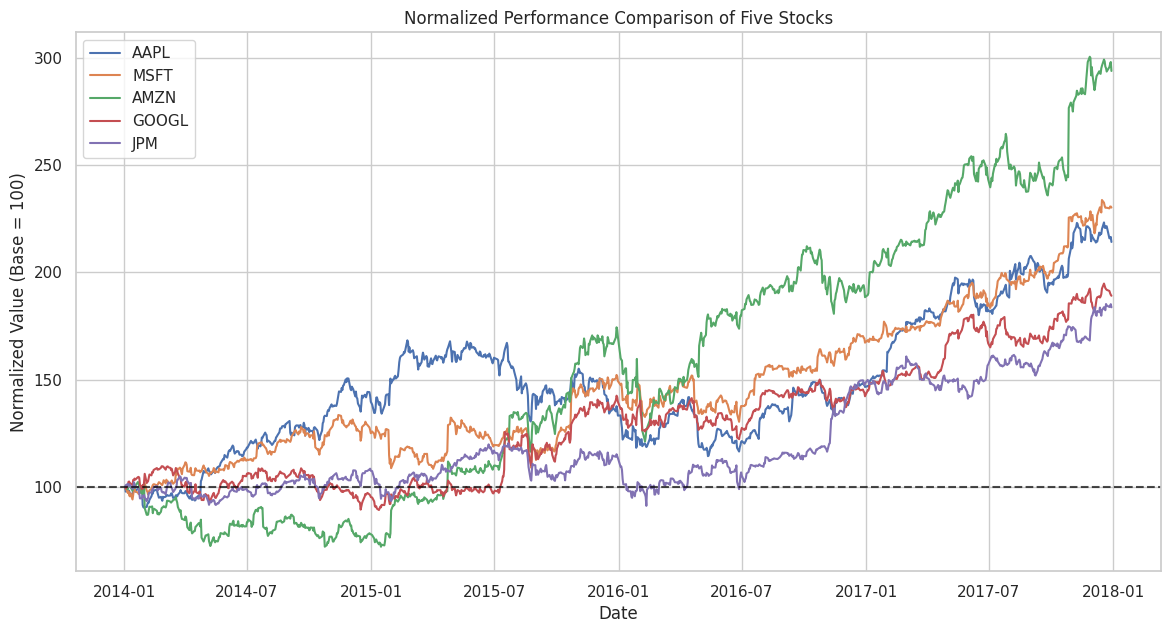

Overall Performance Summary:


,first_close,last_close,total_return_percent
symbol,,,
AMZN,397.9700,1169.47,193.858834
MSFT,37.1600,85.54,130.193757
AAPL,79.0185,169.23,114.165037
GOOGL,557.1166,1053.40,89.080706
JPM,58.2100,106.94,83.714138


In [56]:
requested_stocks = ["AAPL", "MSFT", "AMZN", "GOOGL", "JPM"]

selected_stocks = [
    stock for stock in requested_stocks
    if stock in df_clean["symbol"].unique()
]

print("Selected stocks:", selected_stocks)

comparison_df = (
    df_clean[df_clean["symbol"].isin(selected_stocks)]
    .copy()
    .sort_values(["symbol", "date"])
)


comparison_df["normalized_performance"] = (
    comparison_df.groupby("symbol")["close"]
    .transform(lambda x: (x / x.iloc[0]) * 100)
)

# Performance chart
plt.figure(figsize=(14, 7))

for stock in selected_stocks:
    stock_data = comparison_df[
        comparison_df["symbol"] == stock
    ]

    plt.plot(
        stock_data["date"],
        stock_data["normalized_performance"],
        label=stock
    )

plt.axhline(y=100, color="black", linestyle="--", alpha=0.7)
plt.title("Normalized Performance Comparison of Five Stocks")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")
plt.legend()
plt.show()

# Overall return summary
performance_summary = (
    comparison_df.groupby("symbol")
    .agg(
        first_close=("close", "first"),
        last_close=("close", "last")
    )
)

performance_summary["total_return_percent"] = (
    (performance_summary["last_close"] / performance_summary["first_close"]) - 1
) * 100

performance_summary = performance_summary.sort_values(
    "total_return_percent",
    ascending=False
)

print("Overall Performance Summary:")
display(performance_summary)

**Bonus Challenge 8: Predict Next-Day Closing Price and Compare with Actual Price.**

Next-Day Prediction Results for AAPL:


,Input Date,Forecast Date,Actual Next-Day Close,Predicted Next-Day Close,Prediction Error,Absolute Error
0,2017-06-01,2017-06-02,155.45,153.060147,2.389853,2.389853
1,2017-06-02,2017-06-05,153.93,155.174457,-1.244457,1.244457
2,2017-06-05,2017-06-06,154.45,153.708221,0.741779,0.741779
3,2017-06-06,2017-06-07,155.37,154.608469,0.761531,0.761531
4,2017-06-07,2017-06-08,154.99,155.339940,-0.349940,0.349940
5,2017-06-08,2017-06-09,148.98,154.845108,-5.865108,5.865108
6,2017-06-09,2017-06-12,145.42,149.118913,-3.698913,3.698913
7,2017-06-12,2017-06-13,146.59,144.973421,1.616579,1.616579
8,2017-06-13,2017-06-14,145.16,146.795969,-1.635969,1.635969
9,2017-06-14,2017-06-15,144.29,145.285715,-0.995715,0.995715



Average prediction error: 1.4536


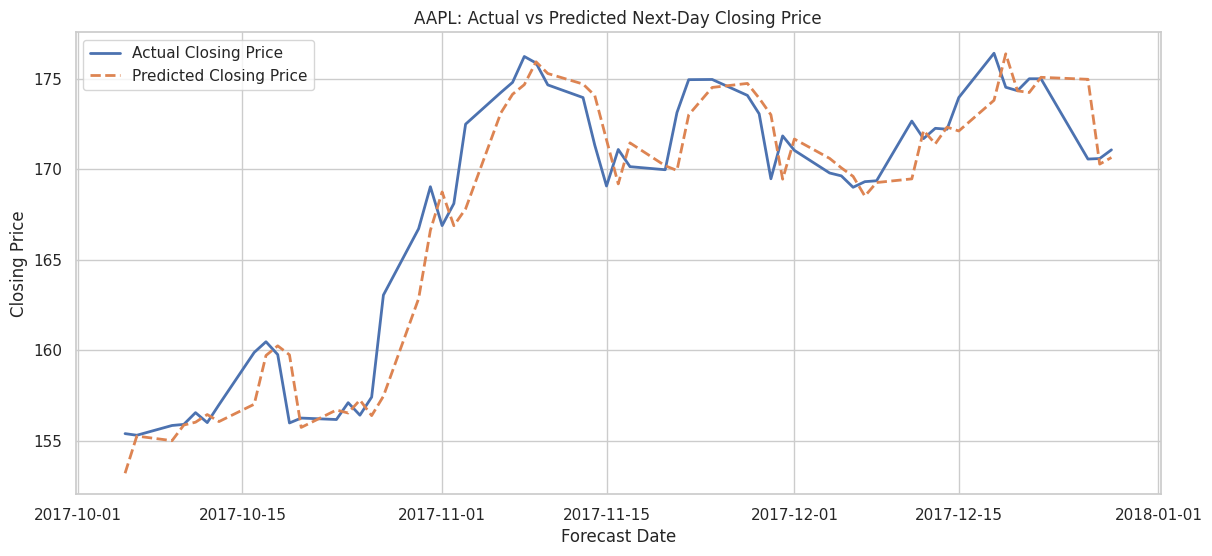

In [57]:
challenge_8_results = pd.DataFrame({
    "Input Date": model_df["date"].iloc[validation_end:].values,
    "Forecast Date": model_df["date"].shift(-1).iloc[validation_end:].values,
    "Actual Next-Day Close": y_test.values,
    "Predicted Next-Day Close": test_predictions
})

challenge_8_results["Prediction Error"] = (
    challenge_8_results["Actual Next-Day Close"] -
    challenge_8_results["Predicted Next-Day Close"]
)

challenge_8_results["Absolute Error"] = (
    challenge_8_results["Prediction Error"].abs()
)

print(f"Next-Day Prediction Results for {model_stock}:")
display(challenge_8_results.head(20))

print("\nAverage prediction error:",
      round(challenge_8_results["Absolute Error"].mean(), 4))


plot_results = challenge_8_results.tail(60)

plt.figure(figsize=(14, 6))

plt.plot(
    plot_results["Forecast Date"],
    plot_results["Actual Next-Day Close"],
    label="Actual Closing Price",
    linewidth=2
)

plt.plot(
    plot_results["Forecast Date"],
    plot_results["Predicted Next-Day Close"],
    label="Predicted Closing Price",
    linewidth=2,
    linestyle="--"
)

plt.title(f"{model_stock}: Actual vs Predicted Next-Day Closing Price")
plt.xlabel("Forecast Date")
plt.ylabel("Closing Price")
plt.legend()
plt.show()